In [1]:
# 라이브러리 버전 확인하기
import konlpy
import gensim
import sklearn
import seaborn

print(konlpy.__version__)
print(gensim.__version__)
print(sklearn.__version__)
print(seaborn.__version__)

0.6.0
4.3.2
1.7.0
0.13.2


## 형태소 분석기를 이용하여 품사가 명사인 경우, 해당 단어 추출하기

### 영화 코퍼스 데이터 불러오기

In [2]:
!cd ~/data && unzip synopsis.zip -d ~/work/weat/data/

Archive:  synopsis.zip
replace /home/jovyan/work/weat/data/synopsis.txt? [y]es, [n]o, [A]ll, [N]one, [r]ename: ^C


In [3]:
import os

data_dir = os.path.join(os.getenv("HOME"), "work/weat/data")
file_name = os.path.join(data_dir, "synopsis.txt")

with open(file_name, 'r') as file:
    for i in range(20):
        print(file.readline(), end='')

사운드 엔지니어 상우(유지태 분)는 치매에 걸린 할머니(백성희 분)와
 젊은 시절 상처한 한 아버지(박인환 분), 고모(신신애 분)와 함께 살고 있다.
 어느 겨울 그는 지방 방송국 라디오 PD 은수(이영애 분)를 만난다.
 자연의 소리를 채집해 틀어주는 라디오 프로그램을 준비하는 은수는 상우와 녹음 여행을 떠난다.
 자연스레 가까워지는 두 사람은 어느 날, 은수의 아파트에서 밤을 보낸다.
 너무 쉽게 사랑에 빠진 두 사람... 상우는 주체할 수 없을 정도로 그녀에게 빨려든다.
 그러나 겨울에 만난 두 사람의 관계는 봄을 지나 여름을 맞이하면서 삐걱거린다.
 이혼 경험이 있는 은수는 상우에게 결혼할 생각이 없다며 부담스러운 표정을 내비친다.
 "어떻게 사랑이 변하니?..."라고 묻는 상우에게 은수는 그저 "헤어져" 라고 단호하게 말한다.
 영원히 변할 것 같지 않던 사랑이 변하고, 그 사실을 받아들이지 못하는 상우는 어찌 할 바를 모른다.
 은수를 잊지 못하는 상우는 미련과 집착의 감정을 이기지 못하고 서울과 강릉을 오간다.
유사 이래 연령, 성별, 빈부의 차이와 정치적인 입장을 불문하고 일거에 국민을 통합해 온 '애국심'이라는 성역에 일침을 가하는 다큐멘터리. 재작년 전국 민족민주 유가족협의회의 장기농성을 다룬 인상적인 다큐멘터리 <민들레>를 만들었던 독립영화집단 '빨간 눈사람'이 우리 사회 구석구석을 발빠르게 돌아다니며 애국심과 민족주의가 강요되는 현장을 발굴하여 카메라에 담았다. 박홍 서강대 명예총장, 이도형 '한국논단' 발행인, 축구해설자 신문선, 홍세화, 박노해 등 사회 각계의 '스타'들이 등장해 저마다의 확고한 신념을 성토한다. 감독 이경순과 최하동하는 이 작품을 위해 3년간 백여 명을 인터뷰했다고 한다. 2001 올해의 독립영화상 수상.
 민족과 국가란 공동체에서 부단히 권력과 부를 얻는 자, 나아가 민족과 국가란 공동체에서 얻은 신분과 부귀를 영원히 그의 자손에게 대물림하려는 자, 그래서 민족과 국가란 공동체를 부단히 유지해야만 하는 자, 따라서

### 품사가 명사인 경우만 남겨 tokenized 변수에 저장

In [ ]:
# konlpy 패키지 다운로드 코드 (이미 있어서 실행 X)

!sudo apt update
!sudo apt install openjdk-17-jdk -y
!echo 'export JAVA_HOME=$(dirname $(dirname $(readlink -f $(which java))))' >> ~/.bashrc
!source ~/.bashrc

!pip install konlpy

In [4]:
from konlpy.tag import Okt

okt = Okt()
tokenized = []

with open(file_name, 'r') as file:
    while True:
        line = file.readline()
        if not line: break
        words = okt.pos(line, stem=True, norm=True)
        res = []
        for w in words:
            if w[1] in ["Noun"]:
                res.append(w[0])    # 명사일 때만 tokenized 에 저장
        tokenized.append(res)

print(len(tokenized))

71156


## 추출된 결과로 embedding model 만들기

**실습과 다르게 진행한 부분**
- sg 파라미터 값을 1로 조정 → **Skip-gram**방식 사용
- 이유  
  1. 이번 프로젝트의 주제인 영화 구분과 장르 간의 편향성 조사를 고려했을 때,  
  시놉시스에는 특정 장르나 예술 영화에서만 쓰이는 독특하고 전문적인 단어들이 많다고 판단
     - 그래서, **저빈도 단어의 의미를 보존**하는 것이 중요했음
        - 데이터 전체의 평균적인 문맥을 보기 땜누에 희소 단어를 뭉뚱그리는 경향이 있는 CBoW보다는
        - 단어 하나하나가 주변 단어를 예측하게 하여 적게 등장하는 핵심 키워드의 벡터 값도 더 정교하게 학습할 수 있는 Skip-gram을 사용하는 편이 유리하다고 생각했습니다.
  2. 사용하는 데이터 synopsis.txt (대략 17MB)
     - 아주 큰 빅데이터는 아님
     - 그래서, 이정도 규모라면 학습 시간이 조금 더 걸리더라도 정확도가 높은 Skip-gram을 선택하는 것이 분석의 신뢰도를 높이는 데 유리하다는 판단

In [5]:
from gensim.models import Word2Vec

# tokenized에 담긴 데이터를 가지고 나만의 Word2Vec을 생성합니다. (Gensim 4.0 기준)
model = Word2Vec(tokenized, vector_size=100, window=5, min_count=3, sg=1) 
# sg 파라미터 -> 0: CBoW, 1: Skip-gram

In [ ]:
### 모델 테스트

In [6]:
model.wv.most_similar(positive=['영화'])

[('영화로', 0.7593558430671692),
 ('작품', 0.7307807207107544),
 ('픽션', 0.7274978160858154),
 ('주제', 0.7207515835762024),
 ('공포영화', 0.7160186171531677),
 ('무성영화', 0.7137002944946289),
 ('서사', 0.7117918729782104),
 ('다큐멘터리', 0.7085081934928894),
 ('극영화', 0.7067031264305115),
 ('블랙코미디', 0.706020712852478)]

In [7]:
model.wv.most_similar(positive=['장르'])

[('상상력', 0.8658108711242676),
 ('미장센', 0.8560079336166382),
 ('미장센단편영화제', 0.8428457975387573),
 ('멜로', 0.8360617160797119),
 ('멜로드라마', 0.8322619795799255),
 ('희극', 0.821901261806488),
 ('내러티브', 0.8183298707008362),
 ('서사', 0.8173338174819946),
 ('걸작', 0.811411440372467),
 ('한국영', 0.8096672892570496)]

In [8]:
model.wv.most_similar(positive=['예술'])

[('문학', 0.7890468835830688),
 ('무용', 0.7837821841239929),
 ('철학', 0.7799981236457825),
 ('예술가', 0.7753022313117981),
 ('조명하', 0.770203709602356),
 ('평가', 0.7679408192634583),
 ('독창', 0.7644842863082886),
 ('한대수', 0.7644618153572083),
 ('전위', 0.7531690001487732),
 ('아이콘', 0.7529178857803345)]

**모델 성능 판단**
- 실험: '영화', '장르', '예술' 3가지 단어에 대해 유사도 계산
- 결과 해석:
    - 연관 단어들이 타당하게 잘 나옴
        - '장르': '멜로', '희극' 과 같은 실제 장르명 뿐 아니라,
          '미장센', '내러티브'와 같은 영화 이론적 단어들이 상위에 포진
        - '예술': '문학', '무용', '철학' 등 예술과 관련 있는 학문과 '전위(아방가르드)', '독창' 과 같은 추상적 가치가 함께 등장
        **즉, 모델이 각 단어를 단순 단어가 아니라 맥락적 요소도 포함하여 개념적으로 이해하고 있다**
    - 최상위 단어들의 유사도 점수가 0.7~0.8점
        - 이 점수대는 너무 높아서 단어끼리 중복되지도 않고, 너무 낮아서 관계가 희미하지도 않는다고 한다
    - 고유 명사와 맥락 파악
        - '미장센단편영화제'나 '한대수' 같은 구체적인 고유 명사가 등장함
          **한국 영화 시놉시스 데이터의 특색을 모델이 잘 반영하고 있음**

## 단어 셋 구성하기

### 데이터셋 확인하기

In [10]:
import os

data_dir = os.path.join(os.getenv("HOME"), "work/weat/data")

def print_synopsis_files(directory):
    # 디렉토리 내 모든 파일 가져오기
    all_files = os.listdir(directory)
    
    # 'synopsis_'로 시작하고 '.txt'로 끝나는 파일만 필터링
    synopsis_files = [f for f in all_files if f.startswith('synopsis_') and f.endswith('.txt')]
    
    print(f"--- [ {directory} ] 내 시놉시스 파일 목록 ---")
    for i, file_name in enumerate(sorted(synopsis_files), 1):
        full_path = os.path.join(directory, file_name)
        
        # 파일의 첫 줄(맛보기) 읽기
        with open(full_path, 'r', encoding='utf-8') as f:
            sample_line = f.readline().strip()
            # 내용이 너무 길면 잘라서 출력
            preview = (sample_line[:50] + '..') if len(sample_line) > 50 else sample_line
        
        print(f"{i:02d}. 파일명: {file_name}")
        print(f"    내용예시: {preview}\n")
    
    print(f"총 {len(synopsis_files)}개의 하위 문서가 확인되었습니다.")

# 실행
print_synopsis_files(data_dir)


--- [ /home/jovyan/work/weat/data ] 내 시놉시스 파일 목록 ---
01. 파일명: synopsis_SF.txt
    내용예시: 시간과 지명을 알 수 없는 한국의 어느 가상 도시. 산성비로 오염된 이 도시에 잊고 싶은 ..

02. 파일명: synopsis_action.txt
    내용예시: 제1부. 4세기 경, 로마 제국에 접한 유라시아 평원에 새로운 민족이 등장했다. 궁술, 승..

03. 파일명: synopsis_adult.txt
    내용예시: 어느 날 사업체를 운영하는 영수에게 막노동을 하는 동생 철민이 찾아온다.

04. 파일명: synopsis_adventure.txt
    내용예시: 인류학자 마이클은 레오나르도 다빈치의 고문서에 보물이 숨겨진 위치에 대한 정보를 알고

05. 파일명: synopsis_animation.txt
    내용예시: 어두운 밤이 오면, 아이들의 벽장 너머 그들이 나타난다!

06. 파일명: synopsis_art.txt
    내용예시: 사운드 엔지니어 상우(유지태 분)는 치매에 걸린 할머니(백성희 분)와

07. 파일명: synopsis_comedy.txt
    내용예시: 카타쿠리 가는 할아버지와 아들 부부, 그들의 아들과 이혼한 딸, 그리고 딸이 낳은 또다른 ..

08. 파일명: synopsis_crime.txt
    내용예시: 선천성 청각 장애인 류(신하균 분)에게 누나(임지은 분)는 유일한 가족이다. 신부전증을 앓..

09. 파일명: synopsis_documentary.txt
    내용예시: 유사 이래 연령, 성별, 빈부의 차이와 정치적인 입장을 불문하고 일거에 국민을 통합해 온 ..

10. 파일명: synopsis_drama.txt
    내용예시: 사운드 엔지니어 상우(유지태 분)는 치매에 걸린 할머니(백성희 분)와

11. 파일명: synopsis_etc.txt
    내용예시: 바닷가의 작은 집에서 남편, 딸과 함께 살고 있는 아나는 남편이 딸과 함께 잠시 집

**데이터셋 구성**
- 배경지식 (KOBIS의 표준 항목)
  1. 영화구분 (Movie Type)
     - 일반영화 (General / gen)
     - 예술영화 (Art Film / art)
     - 이 외의 독립영화, 애니메이션 등은 이 분류 체계 안에 포함되기도 한다
  3. 장르 (Genre)
     - KOBIS 표준 분류에는 21개의 공식 장르가 정해져있다
- **목록의 06번 `synopsis_art.txt`, 14번 `synopsis_gen.txt` 파일은 장르가 아닌 영화 구분 파일**
    - 장르가 아닌 영화구분 파일인 이유 (위의 배경지식 외에도 증거가 존재)
      내용 예시를 보면, 중복되는 내용이 존재
      - art vs drama  
        `06. synopsis_art.txt: "사운드 엔지니어 상우(유지태 분)는 치매에 걸린 할머니..."`  
        `10. synopsis_drama.txt: "사운드 엔지니어 상우(유지태 분)는 치매에 걸린 할머니..."`
      - gen vs documentary  
        `14. synopsis_gen.txt: "유사 이래 연령, 성별, 빈부의 차이와 정치적인 입장을 불문하고 일거에 국민을 통합해 온..."`  
        `09. synopsis_documentary.txt: "유사 이래 연령, 성별, 빈부의 차이와 정치적인 입장을 불문하고 일거에 국민을 통합해 온..."`
- `sysnopsis_SF.txt` 부터 `synopsis_fantasy.txt`까지 **총 21개의 장르 파일**

### target 단어 셋 구성

In [ ]:
#'synopsis_art.txt', 'synopsis_gen.txt' 두 파일을 읽고, 
# 위에서 했던 것과 마찬가지로 명사에 대해서만 추출하여 art, gen 변수에 할당

import os
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np
from konlpy.tag import Okt

art_txt = 'synopsis_art.txt'
gen_txt = 'synopsis_gen.txt'

def read_token(file_name):
    okt = Okt()
    result = []
    with open(data_dir + '/' + file_name, 'r') as fread:
        print(file_name, '파일을 읽고 있습니다.')
        while True:
            line = fread.readline()
            if not line: break
            tokenlist = okt.pos(line, stem=True, norm=True)
            for word in tokenlist:
                if word[1] in ["Noun"]:#, "Adjective", "Verb"]:
                    result.append((word[0]))
    return ' '.join(result)

art = read_token(art_txt)
gen = read_token(gen_txt)

synopsis_art.txt 파일을 읽고 있습니다.
synopsis_gen.txt 파일을 읽고 있습니다.


#### attribute 단어 셋 구성

In [11]:
genre_txt = ['synopsis_SF.txt', 'synopsis_family.txt', 'synopsis_show.txt', 'synopsis_horror.txt', 'synopsis_etc.txt',
             'synopsis_documentary.txt', 'synopsis_drama.txt', 'synopsis_romance.txt', 'synopsis_musical.txt',
             'synopsis_mystery.txt', 'synopsis_crime.txt', 'synopsis_historical.txt', 'synopsis_western.txt',
             'synopsis_adult.txt', 'synopsis_thriller.txt', 'synopsis_animation.txt', 'synopsis_action.txt',
             'synopsis_adventure.txt', 'synopsis_war.txt', 'synopsis_comedy.txt', 'synopsis_fantasy.txt']
genre_name = ['SF', '가족', '공연', '공포(호러)', '기타', '다큐멘터리', '드라마', '멜로로맨스', '뮤지컬', '미스터리', '범죄', '사극', '서부극(웨스턴)',
         '성인물(에로)', '스릴러', '애니메이션', '액션', '어드벤처', '전쟁', '코미디', '판타지']

genre = []
for file_name in genre_txt:
    genre.append(read_token(file_name))

synopsis_SF.txt 파일을 읽고 있습니다.
synopsis_family.txt 파일을 읽고 있습니다.
synopsis_show.txt 파일을 읽고 있습니다.
synopsis_horror.txt 파일을 읽고 있습니다.
synopsis_etc.txt 파일을 읽고 있습니다.
synopsis_documentary.txt 파일을 읽고 있습니다.
synopsis_drama.txt 파일을 읽고 있습니다.
synopsis_romance.txt 파일을 읽고 있습니다.
synopsis_musical.txt 파일을 읽고 있습니다.
synopsis_mystery.txt 파일을 읽고 있습니다.
synopsis_crime.txt 파일을 읽고 있습니다.
synopsis_historical.txt 파일을 읽고 있습니다.
synopsis_western.txt 파일을 읽고 있습니다.
synopsis_adult.txt 파일을 읽고 있습니다.
synopsis_thriller.txt 파일을 읽고 있습니다.
synopsis_animation.txt 파일을 읽고 있습니다.
synopsis_action.txt 파일을 읽고 있습니다.
synopsis_adventure.txt 파일을 읽고 있습니다.
synopsis_war.txt 파일을 읽고 있습니다.
synopsis_comedy.txt 파일을 읽고 있습니다.
synopsis_fantasy.txt 파일을 읽고 있습니다.


### TF-IDF 방식 적용해보기 (실습 코드 사용)

In [12]:
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform([art, gen])

print(X.shape)

(2, 41082)


In [13]:
print(vectorizer.vocabulary_['영화'])
print(vectorizer.get_feature_names_out()[23976])

23976
영화


In [14]:
m1 = X[0].tocoo()   # art를 TF-IDF로 표현한 sparse matrix를 가져옵니다.
m2 = X[1].tocoo()   # gen을 TF-IDF로 표현한 sparse matrix를 가져옵니다.

w1 = [[i, j] for i, j in zip(m1.col, m1.data)]
w2 = [[i, j] for i, j in zip(m2.col, m2.data)]

w1.sort(key=lambda x: x[1], reverse=True)   #art를 구성하는 단어들을 TF-IDF가 높은 순으로 정렬합니다.
w2.sort(key=lambda x: x[1], reverse=True)   #gen을 구성하는 단어들을 TF-IDF가 높은 순으로 정렬합니다.

print('예술영화를 대표하는 단어들:')
for i in range(100):
    print(vectorizer.get_feature_names_out()[w1[i][0]], end=', ')

print('\n')

print('일반영화를 대표하는 단어들:')
for i in range(100):
    print(vectorizer.get_feature_names_out()[w2[i][0]], end=', ')

예술영화를 대표하는 단어들:
그녀, 자신, 시작, 위해, 사랑, 사람, 영화, 친구, 남자, 가족, 이야기, 마을, 사건, 마음, 세상, 아버지, 아이, 엄마, 모든, 여자, 대한, 서로, 과연, 시간, 다시, 아들, 소녀, 아내, 다른, 영화제, 사이, 세계, 사실, 하나, 점점, 남편, 감독, 여행, 인생, 발견, 모두, 순간, 우리, 가장, 마지막, 아빠, 생활, 통해, 모습, 기억, 죽음, 비밀, 학교, 음악, 한편, 소년, 생각, 도시, 명의, 결혼, 사고, 전쟁, 위기, 때문, 이제, 최고, 이자, 과거, 일상, 경찰, 간다, 상황, 미국, 운명, 결심, 관계, 현실, 지금, 단편, 여인, 하루, 이름, 이후, 준비, 인간, 만난, 감정, 처음, 국제, 누구, 살인, 충격, 동안, 존재, 그린, 어머니, 연인, 계속, 동생, 작품, 

일반영화를 대표하는 단어들:
자신, 그녀, 영화제, 위해, 사람, 시작, 국제, 영화, 친구, 사랑, 남자, 이야기, 대한, 서울, 여자, 사건, 남편, 아이, 가족, 아버지, 다른, 마을, 시간, 엄마, 아들, 모든, 단편, 마음, 사실, 다시, 세계, 모습, 작품, 통해, 생각, 서로, 세상, 발견, 감독, 아내, 관계, 소녀, 사이, 하나, 우리, 애니메이션, 때문, 여성, 죽음, 과연, 점점, 인간, 생활, 한편, 결혼, 상황, 모두, 기억, 명의, 소년, 여행, 가장, 간다, 순간, 이제, 도시, 비밀, 학교, 과거, 가지, 이자, 경찰, 마지막, 미국, 동안, 전쟁, 주인공, 대해, 존재, 현실, 연출, 사고, 살인, 일상, 어머니, 계속, 사회, 인생, 다큐멘터리, 부문, 섹스, 최고, 바로, 의도, 동생, 하루, 위기, 계획, 정체, 한국, 

In [15]:
n = 15
w1_, w2_ = [], []
for i in range(100):
    w1_.append(vectorizer.get_feature_names_out()[w1[i][0]])
    w2_.append(vectorizer.get_feature_names_out()[w2[i][0]])

# w1에만 있고 w2에는 없는, 예술영화를 잘 대표하는 단어를 15개 추출한다.
target_art, target_gen = [], []
for i in range(100):
    if (w1_[i] not in w2_) and (w1_[i] in model.wv): target_art.append(w1_[i])
    if len(target_art) == n: break

# w2에만 있고 w1에는 없는, 일반영화를 잘 대표하는 단어를 15개 추출한다.
for i in range(100):
    if (w2_[i] not in w1_) and (w2_[i] in model.wv): target_gen.append(w2_[i])
    if len(target_gen) == n: break

In [18]:
# 최종 추출된 단어 셋 출력
print(f"Final Attribute Sets (n={n})")

print(f"[Target Art (예술영화 대표 단어)]")
print(target_art)
print(f"개수: {len(target_art)}")

print('\n')

print(f"[Target Gen (일반영화 대표 단어)]")
print(target_gen)
print(f"개수: {len(target_gen)}")

# 만약 루브릭 통과를 위해 단어의 '대표성'을 직접 확인하고 싶다면
# 아래와 같이 두 단어 셋에 겹치는 단어가 있는지(교집합) 확인하는 코드를 추가할 수 있습니다.
intersect = set(target_art).intersection(set(target_gen))
print(f"두 집합의 중복 단어: {list(intersect) if intersect else '없음 (중복 제거 성공!)'}")

Final Attribute Sets (n=15)
[Target Art (예술영화 대표 단어)]
['아빠', '음악', '운명', '결심', '지금', '여인', '이름', '이후', '준비', '만난', '감정', '처음', '누구', '충격', '그린']
개수: 15


[Target Gen (일반영화 대표 단어)]
['서울', '애니메이션', '여성', '가지', '주인공', '대해', '연출', '사회', '다큐멘터리', '부문', '섹스', '바로', '의도', '계획', '정체']
개수: 15
두 집합의 중복 단어: 없음 (중복 제거 성공!)


In [19]:
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(genre)

print(X.shape)

(21, 42191)


In [20]:
m = [X[i].tocoo() for i in range(X.shape[0])]

w = [[[i, j] for i, j in zip(mm.col, mm.data)] for mm in m]

for i in range(len(w)):
    w[i].sort(key=lambda x: x[1], reverse=True)
attributes = []
for i in range(len(w)):
    print(genre_name[i], end=': ')
    attr = []
    j = 0
    while (len(attr) < 15):
        if vectorizer.get_feature_names_out()[w[i][j][0]] in model.wv:
            attr.append(vectorizer.get_feature_names_out()[w[i][j][0]])
            print(vectorizer.get_feature_names_out()[w[i][j][0]], end=', ')
        j += 1
    attributes.append(attr)
    print()

SF: 위해, 자신, 지구, 시작, 사람, 인류, 인간, 미래, 우주, 그녀, 로봇, 세계, 모든, 박사, 우주선, 
가족: 엄마, 아빠, 가족, 영화제, 자신, 위해, 친구, 아주르, 아버지, 시작, 그녀, 아들, 국제, 마을, 낙타, 
공연: 오페라, 사랑, 토스카, 실황, 올레, 자신, 카바, 그녀, 공연, 오텔로, 리골레토, 백작, 프레, 베르디, 위해, 
공포(호러): 시작, 위해, 사람, 자신, 친구, 그녀, 사건, 공포, 발견, 죽음, 마을, 가족, 악령, 남자, 좀비, 
기타: 영화제, 국제, 서울, 단편, 영화, 자신, 사람, 이야기, 그녀, 남자, 위해, 시작, 사랑, 뉴미디어, 페스티벌, 
다큐멘터리: 영화제, 영화, 다큐, 국제, 다큐멘터리, 사람, 이야기, 대한, 자신, 감독, 위해, 서울, 우리, 시작, 세계, 
드라마: 자신, 영화제, 그녀, 사람, 사랑, 영화, 위해, 시작, 국제, 남자, 친구, 이야기, 엄마, 여자, 아버지, 
멜로로맨스: 그녀, 사랑, 자신, 시작, 남편, 남자, 여자, 사람, 친구, 섹스, 위해, 마음, 결혼, 서로, 아내, 
뮤지컬: 뮤지컬, 사랑, 에스메랄다, 그녀, 음악, 충무로, 모차르트, 영화, 토스카, 자신, 니웨, 카바, 영화제, 바흐, 프롤, 
미스터리: 사건, 그녀, 시작, 자신, 위해, 사람, 발견, 사고, 진실, 죽음, 기억, 살인, 친구, 아내, 아이, 
범죄: 사건, 위해, 자신, 경찰, 시작, 그녀, 범죄, 조직, 살인, 사람, 마약, 형사, 남자, 모든, 살해, 
사극: 조선, 위해, 시작, 신기전, 사랑, 자신, 아가멤논, 황제, 그녀, 루안, 사람, 운명, 최고, 하선, 전쟁, 
서부극(웨스턴): 서부, 보안관, 위해, 벌린, 카우보이, 그레이프바인, 헨리, 마을, 자신, 개릿, 아이, 시작, 무법자, 프린트, 태구, 
성인물(에로): 그녀, 남편, 마사지, 자신, 섹스, 관계, 영화, 정사, 남자, 위해, 시작, 여자, 유부녀, 마음, 사랑, 
스릴러: 자신, 그녀, 사건, 시

#### TF-IDF를 적용했을 때의 문제점
1. 중복 단어 발생
  - 두 개념축을 구분하는 변별력이 없다

2. 중복 단어를 제거하고 봐도 특정 영화 타입에서만 쓰이는 단어 집합이라 보기 어려움
  - 이름, 주인공 등의 보편적 단어
  - 부문, 연출 등 설명용 텍스트 (영화의 내용이 아니라 시놉시스 하단에 붙는 문구들이 필터링 되지 않은 것 같다)
  - 지금, 이후 등 시간을 나타내는 부사  

3. TF-IDF의 근본적인 문제점
  - 비교 관점의 부재  
    TF-IDF는 해당 문서 내부의 통계에만 한정되었음.
    그래서, 문서 간의 상대적 특징을 직접적으로 반영하지 못하는 문제
  - 의미적 유사도 무시  
    카운트 기반 벡터화 방식이기 때문에 단어들 간의 유사도를 제대로 구하지 못한다

**해결방법 조사**
1. 상대적 TF-IDF 필터링
   각 개념축에서 산출된 TF-IDF 상위 단어 리스트를 서로 비교
   - 순수도 검사: 양쪽 리스트에 공통으로 포함된 중복 단어를 전체 삭제하거나, 점수 차이가 압도적으로 큰 쪽으로만 배정
   - 불용어 확장: 일반적인 불용어 외에도, 데이터셋 특성상 모든 문서에 공통적으로 등장하는 도메인 특화 단어를 추가로 제거  
       - synopsis.txt의 경우 '장면', '출연', '감독' 등

2. 로그 오즈비 (Log-Odds Ratio) 활용
  - 두 집단(A, B) 사이에서 특정 단어가 나타날 확률을 비교하는 통계적 방식
  - 단순히 TF-IDF가 높은 단어가 아니라, **B 집단에 비해 A 집단에서 유독 더 많이 쓰이는 단어**를 찾는 데 유용
  - 방법: 각 단어에 대해 `log( (A에서의 빈도 / A의 나머지 단어 빈도) / (B에서의 빈도 / B의 나머지 단어 빈도) )`를 계산
  - 장점: TF-IDF가 놓치기 쉬운 '상대적 희소성'을 포착  
      - 결과값이 양수(+)로 클수록 A의 대표어, 음수(-)로 클수록 B의 대표어가 된다
      - 0에 가까운 단어는 공통 단어이므로 자동으로 필터링

3. 점별 상호 정보량 (PMI: Pointwise Mutual Information)
  - 단어와 특정 카테고리(개념축) 사이의 결합 확률을 측정하는 방법
  - 방법: `log( P(단어, 카테고리) / (P(단어) * P(카테고리)) )`를 계산
  - 장점: 특정 단어가 전체 문서에서 흔하게 나오더라도(예: '사람'), 특정 카테고리 내에서만 유독 밀집되어 나타나는지를 수치화  
      - **단어가 카테고리 정보를 얼마나 담고 있는가**를 측정하므로 변별력이 매우 높다

4. Word Embedding의 '방향성 벡터' 활용 (분류 기반)
   - 통계적 수치가 아닌, 학습된 임베딩 공간 내의 기하학적 위치를 이용하는 방식
   - 방법:  
      1. A 그룹의 시놉시스 벡터들의 평균($V_A$)과 B 그룹의 평균($V_B$)을 구한다
      2. 두 벡터의 차이($V_A-V_B$)를 구하여 'A다움'을 나타내는 축을 만든다
      3. 후보 단어 벡터들을 이 축에 사영시켜, 축의 양 끝단에 위치한 단어들을 최종 선정한다
   - 장점: 단어의 단순 빈도가 낮아도 의미적으로 해당 개념축의 극단에 서 있는 단어를 정확히 뽑아낼 수 있다

5. 카이제곱 검정 (Chi-Squared Test)
   - 통계적 유의성을 검증하여 "이 단어가 특정 카테고리에 나타나는 것이 우연인가, 필연인가"를 판단
   - 방법: 단어의 출현 빈도와 카테고리 간의 독립성 검정을 수행
   - 장점: p-value가 낮은(유의미한) 단어들만 남김으로써, 데이터 노이즈로 인해 우연히 TF-IDF가 높게 측정된 단어들을 효과적으로 제거

### TF-IDF 개선 및 벡터화 방법 선택

**상대적 TF-IDF 방식과 로그 오즈비 아이디어 사용**
- 과정  
    1. 도메인 특화 불용어 사전 (Stopwords)
    2. 단어 길이 및 모델 존재 여부 필터링
       - 의미 전달이 모호한 한 글자 명사 제거
       - 학습된 Word2Vec 모델의 어휘 사전에 존재하는 단어만 남겨 벡터 연산이 가능하도록 보장
    3. 상대적 변별력 가중치 적용 (로그 오즈비 아이디어) -> target 단어 셋에 적용
       - 특정 집단의 TF-IDF 점수가 비교 집단의 점수보다 일정 비율 (1.5배) 이상 높은 단어만 최종 후보로 선정
- 이유
  많은 개선 방법들이 있었지만 시간 여건 상 복잡한 구현을 동반하기 보다는 간단하면서도 효과적인 방법을 사용하고자 함

In [24]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Target 전용 TF-IDF 재계산 (변수 꼬임 방지)
vectorizer_target = TfidfVectorizer()
X_target = vectorizer_target.fit_transform([art, gen])

m1 = X_target[0].tocoo() # art
m2 = X_target[1].tocoo() # gen

w1 = [[i, j] for i, j in zip(m1.col, m1.data)]
w2 = [[i, j] for i, j in zip(m2.col, m2.data)]

# 단어:점수 형태의 딕셔너리로 변환
art_score = {vectorizer_target.get_feature_names_out()[idx]: score for idx, score in w1}
gen_score = {vectorizer_target.get_feature_names_out()[idx]: score for idx, score in w2}

# 영화 도메인 불용어
stop_words = {
    '영화', '감독', '연출', '출연', '주인공', '이야기', '작품', '부문', '내용', 
    '제작', '개봉', '상영', '자신', '그녀', '그들', '우리', '대한', '대해', '위해',
    '이후', '지금', '모든', '가지', '관객', '모습', '사실', '상황', '이름', '사건'
}

target_art_filtered = []
target_gen_filtered = []

# 예술영화(Art) 타겟 추출
sorted_art = sorted(art_score.items(), key=lambda x: x[1], reverse=True)
for word, score in sorted_art:
    if len(target_art_filtered) >= 15: break
    # 2글자 이상, 모델에 존재, 불용어 제외 조건
    if word in model.wv and len(word) >= 2 and word not in stop_words:
        # 일반영화 점수보다 1.5배 이상 높은 단어만 추출 (상대적 변별력)
        other_score = gen_score.get(word, 0)
        if score > other_score * 1.5: 
            target_art_filtered.append(word)

# 일반영화(Gen) 타겟 추출
sorted_gen = sorted(gen_score.items(), key=lambda x: x[1], reverse=True)
for word, score in sorted_gen:
    if len(target_gen_filtered) >= 15: break
    # 2글자 이상, 모델에 존재, 불용어 제외 조건
    if word in model.wv and len(word) >= 2 and word not in stop_words:
        # 예술영화 점수보다 1.5배 이상 높은 단어만 추출
        other_score = art_score.get(word, 0)
        if score > other_score * 1.5: 
            target_gen_filtered.append(word)

print(f"예술영화(Art) 최종 단어 셋: {target_art_filtered}")
print(f"일반영화(Gen) 최종 단어 셋: {target_gen_filtered}")

예술영화(Art) 최종 단어 셋: ['사랑', '과연', '인생', '아빠', '음악', '여인', '충격', '연인', '청년', '희망', '프랑스', '만남', '파리', '마주', '노래']
일반영화(Gen) 최종 단어 셋: ['영화제', '국제', '서울', '남편', '단편', '관계', '애니메이션', '여성', '섹스', '의도', '부산', '그것', '독립', '경쟁', '소리']


In [25]:
# 기존 stop_words에 장르 특화 불용어 추가
genre_stopwords = {
    '위해', '자신', '시작', '그녀', '모든', '사람', '이야기', '대한', '대해', '관련',
    '영화제', '국제', '서울', '영화', '감독', '연출', '작품', '부문', '가운데', '함께',
    '과연', '사실', '모습', '상황', '통해', '이후', '지금', '우리', '하나', '다른',
    '남자', '여자', '마음', '서로', '인물', '사건', '발견', '아이', '세상', '세계'
}
combined_stopwords = stop_words.union(genre_stopwords)

final_genre_attributes = []

# w와 vectorizer는 Cell 19~20에서 생성된 21개 장르용 변수를 그대로 사용합니다.
for i in range(len(w)):
    attr = []
    j = 0

    while len(attr) < 15 and j < len(w[i]):
        word_idx = w[i][j][0]
        word = vectorizer.get_feature_names_out()[word_idx]

        # 2글자 이상, 모델에 존재, 불용어 제외 조건
        if word in model.wv and len(word) >= 2 and word not in combined_stopwords:
            attr.append(word)
        j += 1
    
    final_genre_attributes.append(attr)
    print(f"{genre_name[i]}: {', '.join(attr)}")

SF: 지구, 인류, 인간, 미래, 우주, 로봇, 박사, 우주선, 외계, 존재, 행성, 정체, 친구, 비밀, 기억
가족: 엄마, 아빠, 가족, 친구, 아주르, 아버지, 아들, 마을, 낙타, 할머니, 씨제이, 동구, 사랑, 학교, 소년
공연: 오페라, 사랑, 토스카, 실황, 올레, 카바, 공연, 오텔로, 리골레토, 백작, 프레, 베르디, 비바, 카르피, 왕자
공포(호러): 친구, 공포, 죽음, 마을, 가족, 악령, 좀비, 소녀, 살인, 비밀, 정체, 저주, 살해, 의문, 점점
기타: 단편, 사랑, 뉴미디어, 페스티벌, 독립, 친구, 엄마, 아시아나, 소녀, 시간, 이미지, 소년, 부산, 기억, 가족
다큐멘터리: 다큐, 다큐멘터리, 여성, 가족, 한국, 환경, 사회, 마을, 노동자, 가장, 기록, 역사, 음악, 미국, 시간
드라마: 사랑, 친구, 엄마, 아버지, 가족, 단편, 아들, 남편, 시간, 소녀, 다시, 관계, 생각, 아내, 마을
멜로로맨스: 사랑, 남편, 친구, 섹스, 결혼, 아내, 관계, 부부, 엄마, 아버지, 점점, 다시, 회사, 시간, 사이
뮤지컬: 뮤지컬, 사랑, 에스메랄다, 음악, 충무로, 모차르트, 토스카, 니웨, 카바, 바흐, 프롤, 페뷔스, 모도, 카르피, 샤오캉
미스터리: 사고, 진실, 죽음, 기억, 살인, 친구, 아내, 민혁, 의문, 미스터리, 형사, 비밀, 마을, 경찰, 현우
범죄: 경찰, 범죄, 조직, 살인, 마약, 형사, 살해, 수사, 한길수, 범인, 계획, 은행, 작전, 아버지, 동료
사극: 조선, 신기전, 사랑, 아가멤논, 황제, 루안, 운명, 최고, 하선, 전쟁, 윤서, 트로이, 히파티아, 신재효, 채선
서부극(웨스턴): 서부, 보안관, 벌린, 카우보이, 그레이프바인, 헨리, 마을, 개릿, 무법자, 프린트, 태구, 마적, 현상금, 분노, 랜던
성인물(에로): 남편, 마사지, 섹스, 관계, 정사, 유부녀, 사랑, 에피소드, 그린, 아내, 다시, 자위, 회사, 친구, 불륜
스릴러: 살인, 아내, 경찰, 친구, 살해, 가족, 형사,

In [26]:
# 뒤의 WEAT 계산을 위해 변수 덮어쓰기
target_art = target_art_filtered
target_gen = target_gen_filtered
attributes = final_genre_attributes

## WEAT score 계산 및 시각화

### 계산 준비 (WEAT 구현)

In [27]:
# 라이브러리 불러오기
import numpy as np
from numpy import dot
from numpy.linalg import norm

In [28]:
# 코사인 유사도, s함수 구현
def cos_sim(i, j):
    return dot(i, j.T)/(norm(i)*norm(j))

def s(w, A, B):
    c_a = cos_sim(w, A)
    c_b = cos_sim(w, B)
    mean_A = np.mean(c_a, axis=-1)
    mean_B = np.mean(c_b, axis=-1)
    return mean_A - mean_B

In [29]:
# WEAT score 함수 구현
def weat_score(X, Y, A, B):

    s_X = s(X, A, B)
    s_Y = s(Y, A, B)

    mean_X = np.mean(s_X)
    mean_Y = np.mean(s_Y)

    std_dev = np.std(np.concatenate([s_X, s_Y], axis=0))

    return  (mean_X-mean_Y)/std_dev

### 계산

In [30]:
matrix = [[0 for _ in range(len(genre_name))] for _ in range(len(genre_name))]

In [31]:
X = np.array([model.wv[word] for word in target_art])
Y = np.array([model.wv[word] for word in target_gen])

for i in range(len(genre_name)-1):
    for j in range(i+1, len(genre_name)):
        A = np.array([model.wv[word] for word in attributes[i]])
        B = np.array([model.wv[word] for word in attributes[j]])
        matrix[i][j] = weat_score(X, Y, A, B)

In [32]:
for i in range(len(genre_name)-1):
    for j in range(i+1, len(genre_name)):
        print(genre_name[i], genre_name[j],matrix[i][j])

SF 가족 -0.3361921
SF 공연 -0.29173407
SF 공포(호러) -0.3792529
SF 기타 1.0209684
SF 다큐멘터리 0.5910491
SF 드라마 0.22632125
SF 멜로로맨스 0.12867762
SF 뮤지컬 0.22429669
SF 미스터리 -0.14546831
SF 범죄 0.3824088
SF 사극 -0.21681236
SF 서부극(웨스턴) -0.50975937
SF 성인물(에로) 0.39320573
SF 스릴러 -0.060793895
SF 애니메이션 1.0675606
SF 액션 0.111945026
SF 어드벤처 -0.33894584
SF 전쟁 0.41750905
SF 코미디 -0.3107743
SF 판타지 0.53086984
가족 공연 0.01460882
가족 공포(호러) 0.09558096
가족 기타 1.119104
가족 다큐멘터리 0.706544
가족 드라마 0.9141879
가족 멜로로맨스 0.5007496
가족 뮤지컬 0.43971238
가족 미스터리 0.26258728
가족 범죄 0.7284613
가족 사극 0.17034659
가족 서부극(웨스턴) -0.08708544
가족 성인물(에로) 0.69737685
가족 스릴러 0.37435308
가족 애니메이션 1.1032559
가족 액션 0.5054379
가족 어드벤처 0.22217005
가족 전쟁 0.51940113
가족 코미디 0.14709467
가족 판타지 0.6636576
공연 공포(호러) 0.06267323
공연 기타 1.2637123
공연 다큐멘터리 0.87182623
공연 드라마 0.5582605
공연 멜로로맨스 0.3835319
공연 뮤지컬 0.9840826
공연 미스터리 0.18118352
공연 범죄 0.5959368
공연 사극 0.2899482
공연 서부극(웨스턴) -0.13849479
공연 성인물(에로) 0.69383734
공연 스릴러 0.2333164
공연 애니메이션 1.2692568
공연 액션 0.41763276
공연 어드벤처 0.162586

### 계산 결과 해석

1. 수치 해석 기준: `장르A`, `장르B`, `score`  
   - score > 0 : 장르A가 예술영화에 가깝고 장르B가 일반영화에 가깝다는 의미
   - score < 0 : 장르A가 일반영화에 가깝고 장르B가 예술영화에 가깝다는 의미
   - 절댓값의 크기: 0에 가까울수록 편향이 없고 1에 가까울수록 강한 편향성을 띤다

2. 주요 결과
  - 일반영화에 편향이 큰 장르: `애니메이션`, `기타`
    - 서부극(웨스턴) vs. 애니메이션 : 1.328
    - 공연 vs. 애니메이션 : 1.269
    - 기타 vs. 서부극 : -1.340
    - 기타 vs. 사극 : -1.256
  - 예술영화에 편향이 큰 장르: `서부극`, `어드벤처`, `사극`, `공연`
    - 기타 vs. 어드벤처 : -1.268
    - 범죄 vs. 서부극 : -0.855
    - 사극 vs. 애니메이션 : 1.252
    - 공연 vs. 기타 : 1.263
  - 인간의 직관과 모델 학습의 차이: `다큐멘터리`, `드라마`
    - 가족 vs. 다큐멘터리 : 0.706
    - 다큐멘터리 vs. 사극 : -0.863
    - 다큐멘터리 vs. 애니메이션 : 0.798
  - 편향성이 적은 중간 지대의 장르들
    - SF vs. 가족 : -0.336
    - 스릴러 vs. 판타지 : 0.379
    - 멜로로맨스 vs. 뮤지컬 : 0.063

### 시각화

#### 히트맵 시각화

In [33]:
# 구글 코랩(Google Colab) 환경에서 한글 폰트(나눔고딕)를 설치하고 그래프에 적용하기 위한 설정 코드

# 권한 문제 떠서 sudo를 추가함
!sudo apt-get update -qq
!sudo apt-get install -qq fonts-nanum

import matplotlib.pyplot as plt

import matplotlib.font_manager as fm
font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
fm.fontManager.addfont(font_path)
plt.rc('font', family='NanumGothic')

<Axes: >

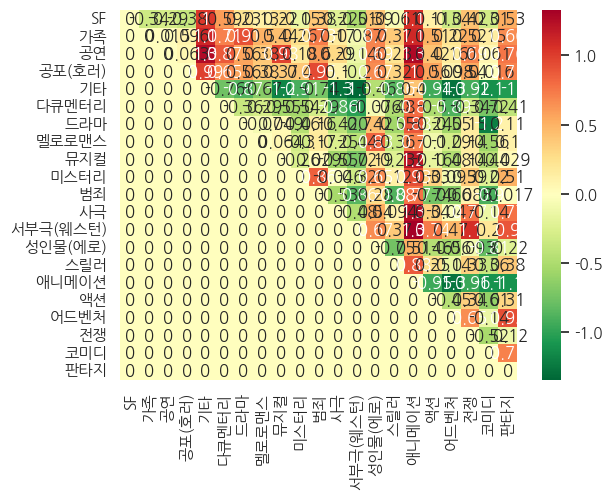

In [34]:
import numpy as np;
import seaborn as sns;

np.random.seed(0)

# 한글 지원 폰트
sns.set(font='NanumGothic')

# 마이너스 부호
plt.rcParams['axes.unicode_minus'] = False

ax = sns.heatmap(matrix, xticklabels=genre_name, yticklabels=genre_name, annot=True,  cmap='RdYlGn_r')
ax

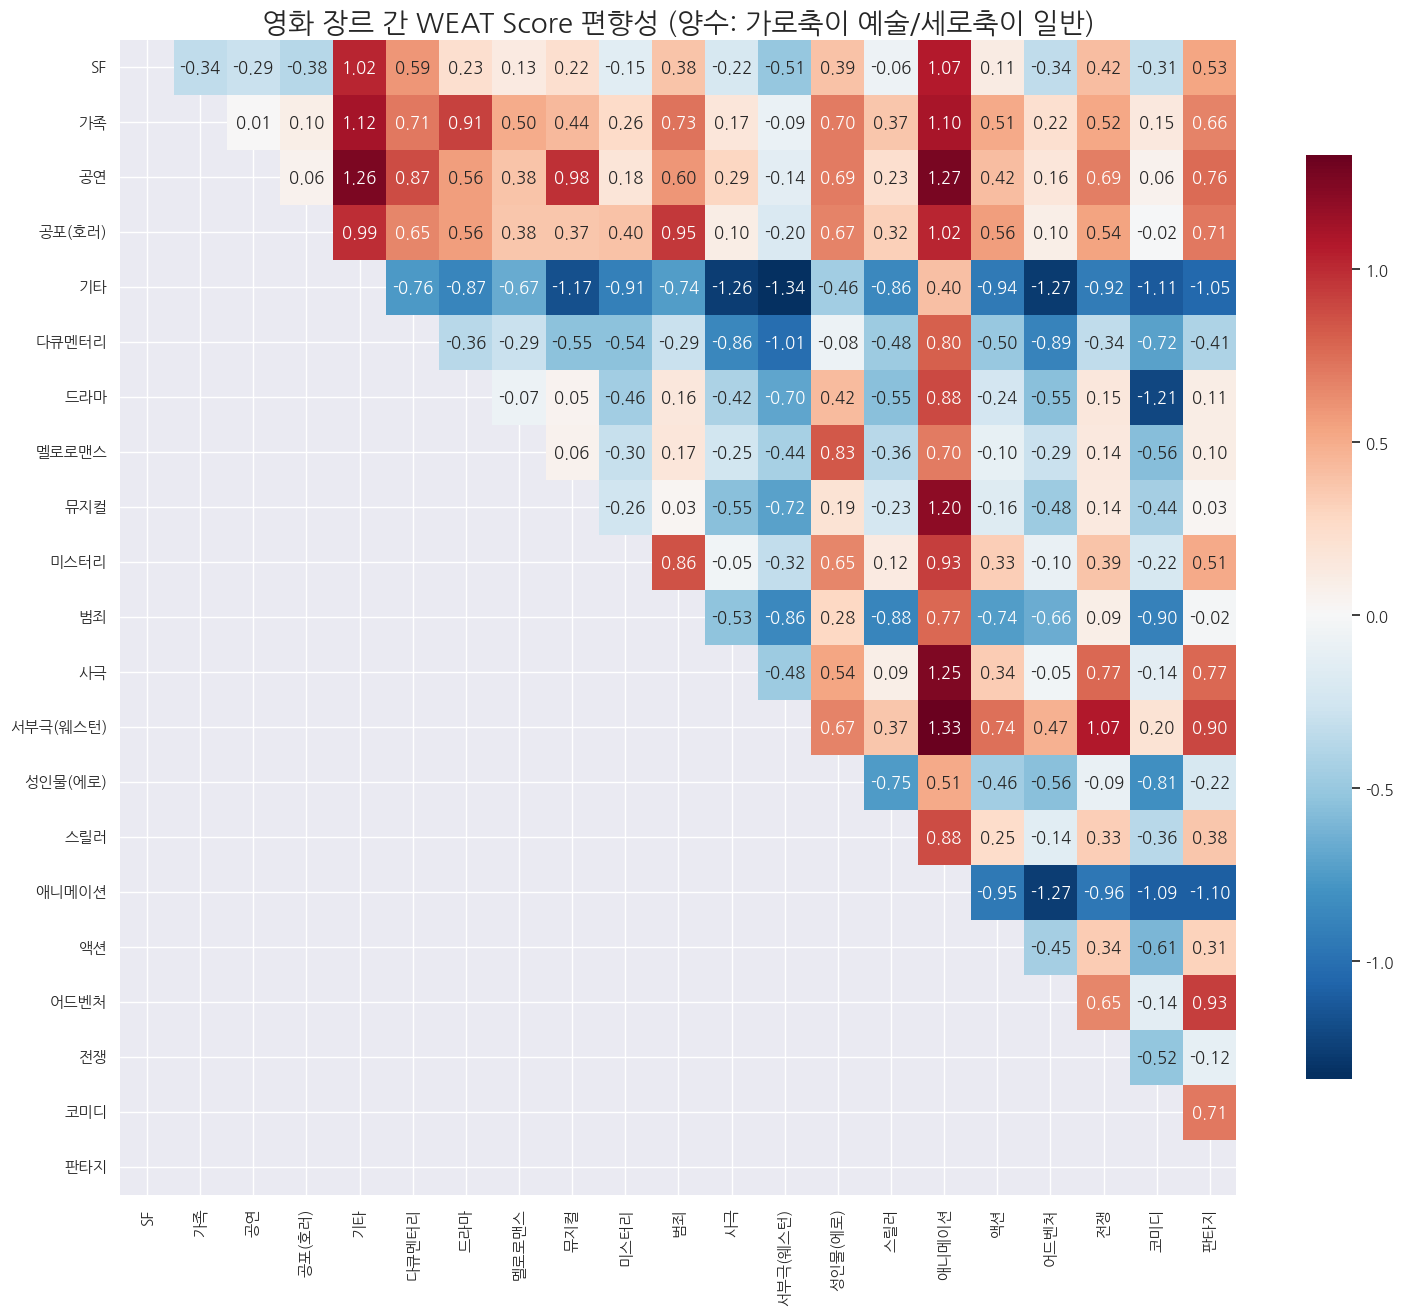

In [37]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(18, 15)) # 그래프 크기를 대폭 키움

# 1. 값이 없는 하삼각(대각선 아래) 부분을 가리기 위한 마스크 생성
mask = np.zeros_like(matrix, dtype=bool)
mask[np.tril_indices_from(mask)] = True 

# 2. 양수(+)와 음수(-)가 명확히 구분되도록 색상 맵(cmap)을 'RdBu_r'로 변경하고 기준점(center)을 0으로 설정
ax = sns.heatmap(matrix, mask=mask, 
                 xticklabels=genre_name, yticklabels=genre_name, 
                 annot=True, fmt=".2f", # 소수점 둘째자리까지만 출력
                 cmap='RdBu_r', center=0, 
                 cbar_kws={"shrink": .8})

plt.title("영화 장르 간 WEAT Score 편향성 (양수: 가로축이 예술/세로축이 일반)", fontsize=20)
plt.show()

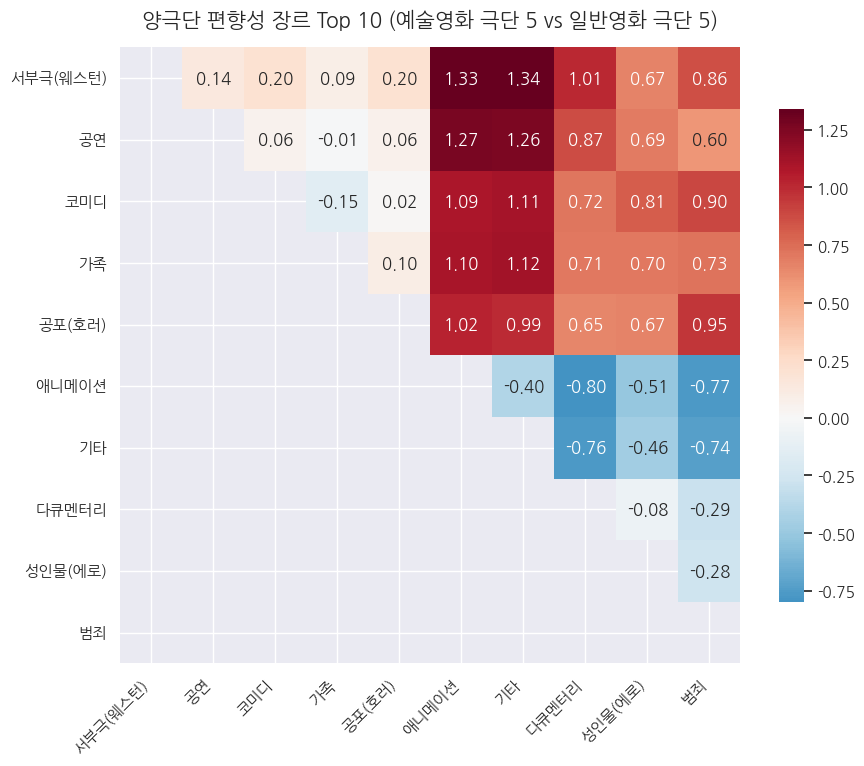

In [38]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 1. 상삼각(절반)에만 채워진 기존 matrix를 온전한 대칭 행렬로 만듭니다.
# (A vs B 가 0.5라면, B vs A 는 -0.5가 되도록 설정)
num_genres = len(genre_name)
full_matrix = np.zeros((num_genres, num_genres))

for i in range(num_genres):
    for j in range(num_genres):
        if i < j:
            full_matrix[i][j] = matrix[i][j]
        elif i > j:
            full_matrix[i][j] = -matrix[j][i]
            
# 2. 각 장르별 평균 편향성 점수를 계산합니다.
# 평균 점수가 양수일수록 '예술영화' 쪽에, 음수일수록 '일반영화' 쪽에 가깝다는 뜻입니다.
genre_scores = np.mean(full_matrix, axis=1)

# 3. 점수를 기준으로 순위를 매깁니다. (오름차순 정렬: 음수 -> 양수)
sorted_indices = np.argsort(genre_scores) 

# 일반영화(Gen) 쪽에 가장 치우친 Top 5 (가장 점수가 낮은 5개)
gen_top5_idx = sorted_indices[:5]
# 예술영화(Art) 쪽에 가장 치우친 Top 5 (가장 점수가 높은 5개)
art_top5_idx = sorted_indices[-5:]

# 시각화를 위해 10개 장르의 인덱스를 합칩니다. 
# (비교를 극대화하기 위해: 예술 1~5위 + 일반 1~5위 순서로 배치)
selected_idx = np.concatenate((art_top5_idx[::-1], gen_top5_idx)) 
selected_genres = [genre_name[i] for i in selected_idx]

# 4. 선택된 10개 장르만으로 10x10 서브 행렬을 만듭니다.
sub_matrix = np.zeros((10, 10))
for i in range(10):
    for j in range(10):
        sub_matrix[i][j] = full_matrix[selected_idx[i]][selected_idx[j]]

# 5. 10x10 히트맵 시각화 진행
plt.figure(figsize=(10, 8))

# 하삼각 가리기 마스크 (10x10)
mask = np.zeros_like(sub_matrix, dtype=bool)
mask[np.tril_indices_from(mask)] = True

# 히트맵 그리기
ax = sns.heatmap(sub_matrix, mask=mask, 
                 xticklabels=selected_genres, yticklabels=selected_genres, 
                 annot=True, fmt=".2f", 
                 cmap='RdBu_r', center=0, 
                 cbar_kws={"shrink": .8})

plt.title("양극단 편향성 장르 Top 10 (예술영화 극단 5 vs 일반영화 극단 5)", fontsize=15, pad=15)
plt.xticks(rotation=45, ha='right') # x축 글씨 겹치지 않게 회전
plt.show()

#### PCA 시각화

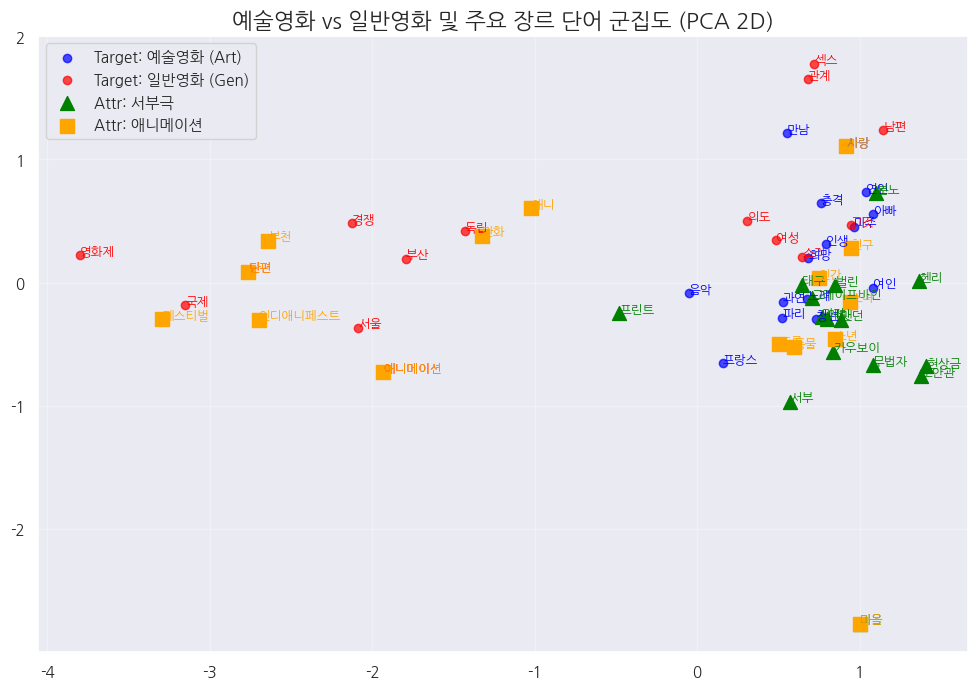

In [36]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# 시각화할 장르 2개를 명시적으로 선택 
# (가장 편향이 컸던 서부극과 애니메이션)
idx_A = genre_name.index('서부극(웨스턴)')
idx_B = genre_name.index('애니메이션')

words_X = target_art
words_Y = target_gen
words_A = attributes[idx_A]
words_B = attributes[idx_B]

# 1. 모든 단어와 벡터를 하나의 리스트로 통합
all_words = words_X + words_Y + words_A + words_B
all_vectors = np.array([model.wv[word] for word in all_words])

# 2. 통합된 벡터 공간에서 딱 한 번만 PCA를 수행 (매우 중요!)
pca = PCA(n_components=2)
pc_all = pca.fit_transform(all_vectors)

# 3. 차원 축소된 결과를 다시 그룹별로 분할 (각각 15개씩)
pc_X = pc_all[0:15]
pc_Y = pc_all[15:30]
pc_A = pc_all[30:45]
pc_B = pc_all[45:60]

# 4. 시각화 진행
plt.figure(figsize=(12, 8))

# 산점도 그리기
plt.scatter(pc_X[:,0], pc_X[:,1], c='blue', label='Target: 예술영화 (Art)', alpha=0.7)
plt.scatter(pc_Y[:,0], pc_Y[:,1], c='red', label='Target: 일반영화 (Gen)', alpha=0.7)
plt.scatter(pc_A[:,0], pc_A[:,1], c='green', label='Attr: 서부극', marker='^', s=100)
plt.scatter(pc_B[:,0], pc_B[:,1], c='orange', label='Attr: 애니메이션', marker='s', s=100)

# 단어 이름표(텍스트) 달아주기
for i, word in enumerate(words_X): plt.annotate(word, (pc_X[i,0], pc_X[i,1]), fontsize=9, color='blue')
for i, word in enumerate(words_Y): plt.annotate(word, (pc_Y[i,0], pc_Y[i,1]), fontsize=9, color='red')
for i, word in enumerate(words_A): plt.annotate(word, (pc_A[i,0], pc_A[i,1]), fontsize=9, color='green')
for i, word in enumerate(words_B): plt.annotate(word, (pc_B[i,0], pc_B[i,1]), fontsize=9, color='orange')

plt.title("예술영화 vs 일반영화 및 주요 장르 단어 군집도 (PCA 2D)", fontsize=16)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 회고

워드임베딩 모델의 인자들부터 단어 셋 구축, 벡터화, 시각화까지의 과정을 직접 설계하며 진행할 수 있어 편향성 조사에 대해 깊은 이해도를 가질 수 있게 되었다.  

WEAT score 결과도
  - 시놉시스에 사용된 텍스트를 기준으로 '애니메이션', '기타'는 일반영화에 치우치고 '서부극', '어드벤처', '사극', '공연'은 예술영화에 치우치는 인간과 비슷한 편향성을 확인할 수 있었다
  - 또한, 사람의 직관으로 봤을 때에 '다큐멘터리'나 '드라마'가 예술영화에 속할 것이라 볼 수도 있는데 '가족'이나 '사극'과 같은 장르와 비교했을 때 오히려 '일반영화'에 더 가까운 결과를 확인할 수 있었다.
      - 즉, 영화 장르 간의 상대적인 언어 사용 스펙트럼이 존재한다는 것을 확인할 수 있었다
   - SF-가족, 스릴러-판타지, 멜로로맨스-뮤지컬 등 절댓값이 0.3 이하로 작게 나오는 쌍들. 편향성이 적은 중간 지대의 장르들도 확인할 수 있었다  

또한, 시각화 결과도 히트맵의 경우 3번에 걸쳐 진행하였는데  
마지막 히트맵을 보면 편향성이 큰 장르들에 대해서 한눈에 살펴보기 좋게 되었고,  
가장 편향성이 크게 나왔던 '서부극'-'애니메이션' 쌍에 대해 PCA 시각화를 진행해 단어 군집도로도 편향을 확인할 수 있었다
   - 파란색 점(예술영화)이 초록색 세모(서부극)과 가깝고
   - 분홍색 점(일반영화)이 노란색 네모(애니메이션)과 가깝다

이렇게 의미 있는 결과도 얻을 수 있어 좋았다.  
향후에는 TF-IDF 방식이 가진 문제점의 해결 방법으로 조사했던 다른 벡터화 방식들도 적용해 보고 싶다.